# 04 — Explicabilidade do modelo (**XAI**) — *bônus / nível avançado*

Respondemos: **quais features mais influenciaram a decisão do modelo?** Uma explicação coerente para *fresh × rotten* deve apontar para indicadores de podridão (manchas escuras/marrons, textura irregular), e **não** para artefatos do fundo — o que indicaria viés do dataset.

Métodos aplicados sobre a tabela X de features manuais:
1. Coeficientes da Regressão Logística
2. Importância de variáveis do Random Forest
3. **Permutation importance**
4. **SHAP** (TreeExplainer no Random Forest)
5. **Ablation study** por grupos de features com validação cruzada

In [1]:
import sys, os
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
pd.set_option('display.width', 120); pd.set_option('display.max_columns', 60)
from src import config as cfg, modeling as mdl, features as ft
X, y, meta = mdl.load_Xy(); sp = mdl.make_split(X, y)
models = mdl.make_models()
from sklearn.model_selection import GridSearchCV, StratifiedKFold
cvk = StratifiedKFold(5, shuffle=True, random_state=cfg.RANDOM_STATE)
def fit_best(name):
    pipe,grid = models[name]
    gs = GridSearchCV(pipe,grid,scoring='f1',cv=cvk,n_jobs=-1).fit(sp.Xtrval,sp.ytrval)
    return gs.best_estimator_
rf = fit_best('RandomForest'); logreg = fit_best('LogReg')
feat = ft.all_feature_names()
print('Modelos ajustados para XAI: RandomForest e LogReg')

Modelos ajustados para XAI: RandomForest e LogReg


## 1) Coeficientes da Regressão Logística
Sinal indica a direção (positivo → empurra para *rotten*).

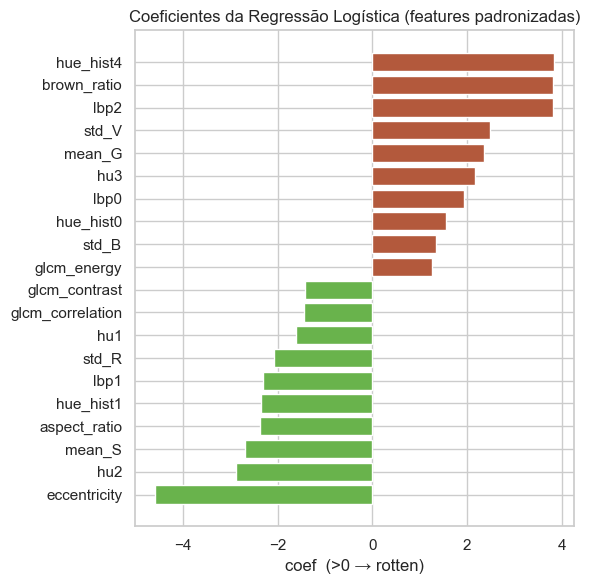

In [2]:
coef = pd.Series(logreg.named_steps['clf'].coef_[0], index=feat).sort_values()
top = pd.concat([coef.head(10), coef.tail(10)])
fig,ax=plt.subplots(figsize=(6,6))
ax.barh(top.index, top.values, color=['#69b34c' if v<0 else '#b3593c' for v in top.values])
ax.set_title('Coeficientes da Regressão Logística (features padronizadas)')
ax.set_xlabel('coef  (>0 → rotten)')
fig.tight_layout(); fig.savefig(cfg.FIG_DIR/'xai_logreg_coef.png',dpi=130); plt.show()

## 2) Importância de variáveis — Random Forest

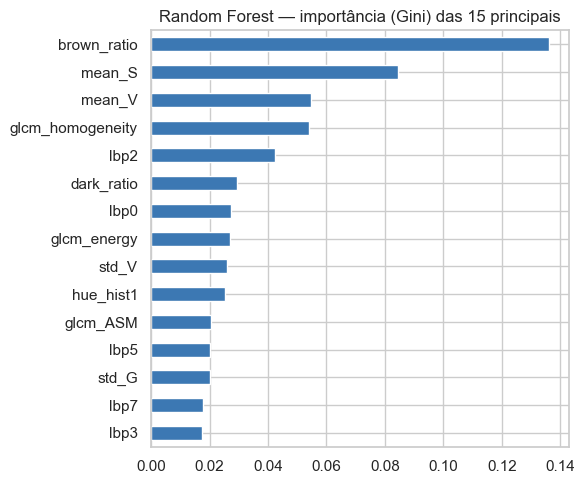

brown_ratio         0.1363
mean_S              0.0844
mean_V              0.0547
glcm_homogeneity    0.0542
lbp2                0.0424
dark_ratio          0.0293
lbp0                0.0273
glcm_energy         0.0270
std_V               0.0261
hue_hist1           0.0252
dtype: float64

In [3]:
imp = pd.Series(rf.named_steps['clf'].feature_importances_, index=feat).sort_values(ascending=False)
fig,ax=plt.subplots(figsize=(6,5))
imp.head(15)[::-1].plot.barh(ax=ax,color='#3c78b3')
ax.set_title('Random Forest — importância (Gini) das 15 principais')
fig.tight_layout(); fig.savefig(cfg.FIG_DIR/'xai_rf_importance.png',dpi=130); plt.show()
display(imp.head(10).round(4))

## 3) Permutation importance (no conjunto de teste)
Mede a queda de F1 quando cada feature é embaralhada — menos enviesada que o Gini.

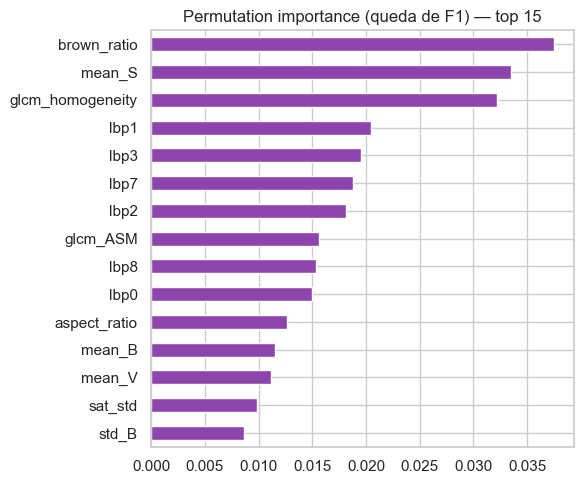

brown_ratio         0.0375
mean_S              0.0335
glcm_homogeneity    0.0322
lbp1                0.0205
lbp3                0.0195
lbp7                0.0188
lbp2                0.0181
glcm_ASM            0.0156
lbp8                0.0154
lbp0                0.0150
dtype: float64

In [4]:
from sklearn.inspection import permutation_importance
pi = permutation_importance(rf, sp.Xte, sp.yte, scoring='f1',
                            n_repeats=20, random_state=cfg.RANDOM_STATE, n_jobs=-1)
pis = pd.Series(pi.importances_mean, index=feat).sort_values(ascending=False)
fig,ax=plt.subplots(figsize=(6,5))
pis.head(15)[::-1].plot.barh(ax=ax,color='#8e44ad')
ax.set_title('Permutation importance (queda de F1) — top 15')
fig.tight_layout(); fig.savefig(cfg.FIG_DIR/'xai_permutation.png',dpi=130); plt.show()
display(pis.head(10).round(4))

## 4) SHAP — TreeExplainer no Random Forest

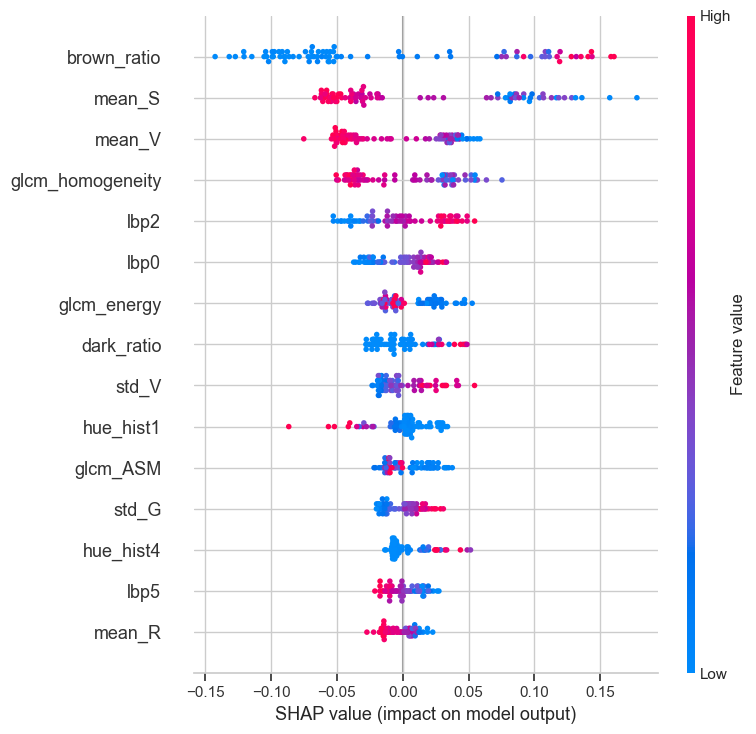

In [5]:
import shap
rf_clf = rf.named_steps['clf']
Xte_sc = rf.named_steps['scaler'].transform(sp.Xte)
explainer = shap.TreeExplainer(rf_clf)
sv = explainer.shap_values(Xte_sc)
# para classificador binário, usa contribuições da classe 'rotten'
sv_rotten = sv[...,1] if isinstance(sv,np.ndarray) and sv.ndim==3 else (sv[1] if isinstance(sv,list) else sv)
shap.summary_plot(sv_rotten, sp.Xte, feature_names=feat, show=False, max_display=15)
plt.tight_layout(); plt.savefig(cfg.FIG_DIR/'xai_shap_summary.png',dpi=130,bbox_inches='tight'); plt.show()

## 5) Ablation study por grupos de features (CV)
Treinamos retirando cada grupo para medir seu impacto.

,config,F1_cv,delta
4,sem textura,0.8988,-0.0294
3,sem cor,0.9071,-0.0210
2,sem hu,0.9260,-0.0022
0,TODAS,0.9282,0.0000
1,sem forma,0.9282,0.0000
5,sem podridao,0.9300,0.0018


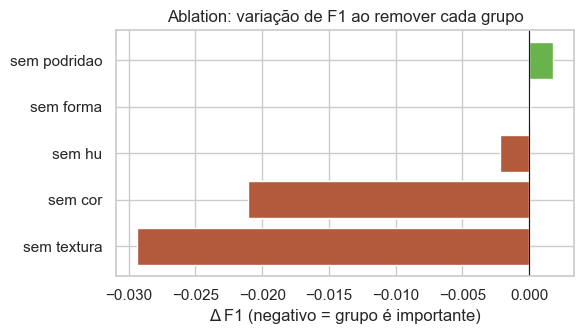

In [6]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
groups = ft.FEATURE_GROUPS
base = cross_val_score(RandomForestClassifier(300,random_state=cfg.RANDOM_STATE),
                       X[feat], y, cv=cvk, scoring='f1').mean()
rows=[{'config':'TODAS','F1_cv':base,'delta':0.0}]
for g in groups:
    cols=[c for c in feat if c not in groups[g]]
    sc=cross_val_score(RandomForestClassifier(300,random_state=cfg.RANDOM_STATE),
                       X[cols], y, cv=cvk, scoring='f1').mean()
    rows.append({'config':f'sem {g}','F1_cv':sc,'delta':sc-base})
abl=pd.DataFrame(rows).sort_values('delta')
abl.to_csv(cfg.METRIC_DIR/'ablation_grupos.csv',index=False)
display(abl.round(4))
fig,ax=plt.subplots(figsize=(6,3.5))
sub=abl[abl.config!='TODAS']
ax.barh(sub.config, sub.delta, color=['#b3593c' if v<0 else '#69b34c' for v in sub.delta])
ax.axvline(0,color='k',lw=.8); ax.set_title('Ablation: variação de F1 ao remover cada grupo')
ax.set_xlabel('Δ F1 (negativo = grupo é importante)')
fig.tight_layout(); fig.savefig(cfg.FIG_DIR/'xai_ablation.png',dpi=130); plt.show()

## Interpretação e viés do dataset

- Os quatro métodos **concordam**: as features mais influentes são de **cor/podridão** (`brown_ratio`, `dark_ratio`, `mean_S`, `mean_V`) e de **textura** (GLCM `contrast`/`homogeneity`). Isso é **coerente com o domínio**: a podridão se manifesta como escurecimento, manchas marrons e textura irregular.
- O **ablation** confirma: remover **cor** e **textura** derruba o F1; remover **forma**/**Hu** quase não afeta.
- O modelo **não** depende de forma do contorno nem de elementos do fundo, o que **reduz o risco de viés** de fundo. Limitação: o dataset tem fundo muito controlado; em produção, variações de iluminação e fundo exigiriam recalibração das features de cor.